## EEG BrainLat — Modelos de Machine Learning
### 3_ML_Models

---

**Objetivo:** treinar e avaliar classificadores AD vs HC com dois esquemas de validação cruzada respeitando a estrutura de sujeitos:

| Esquema | Estratégia | Folds | Observação |
|---------|-----------|-------|------------|
| **LOSO** | `LeaveOneGroupOut` | N sujeitos | Avaliação mais conservadora; 1 sujeito de teste por vez |
| **GroupKFold** | `GroupKFold(k=10)` | 10 | Mais eficiente; grupos de sujeitos nos folds |

> **Por que GroupKFold e não KFold padrão?**
> Épocas do mesmo sujeito são correlacionadas entre si. Um `KFold` padrão poderia colocar épocas
> do sujeito X simultaneamente em treino e teste, causando **data leakage** e AUC artificialmente inflada.
> Ambos os esquemas acima garantem que **nenhum sujeito aparece ao mesmo tempo em treino e teste**.

---

#### Estrutura do Notebook

| Fase | Descrição |
|------|-----------|
| **0 — Configuração** | Imports, caminhos e constantes |
| **1 — Dados** | Carregamento, limpeza e resumo exploratório |
| **2 — LOSO** | Validação Leave-One-Subject-Out |
| **3 — GroupKFold** | Validação K-Fold com grupos de sujeitos |
| **4 — Comparação** | Análise comparativa LOSO vs GroupKFold |
| **5 — Importância** | SHAP e importância de features |

---


---
### Fase 0 — Configuração Global


In [29]:
# 0.1 -- Imports
import os
import warnings
import traceback
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    recall_score, precision_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    balanced_accuracy_score,
)
from xgboost import XGBClassifier
from scipy.stats import wilcoxon, mannwhitneyu

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP não instalado. Execute: pip install shap")

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

SEED = 42
np.random.seed(SEED)
print("Imports carregados com sucesso.")


Imports carregados com sucesso.


In [30]:
# 0.2 -- Constantes e Configuração
IN_CSV     = "eeg_features_brainlat_FULL.csv"   # Gerado pelo 2_Preprocessing
N_SPLITS_KF = 10   # Número de folds para GroupKFold

# Features idênticas às definidas no 2_Preprocessing
FEATURE_COLS = [
    # Espectrais
    "Rel_Theta_mean", "Rel_Alpha_mean", "Rel_Beta_mean", "Rel_Gamma_mean",
    "Razao_Theta_Alpha", "Razao_Theta_Beta", "Spectral_Entropy",
    # Conectividade Funcional
    "PLV_Theta_mean", "PLV_Alpha_mean", "PLV_Beta_mean",
    "Corr_Broadband_mean",
]

print(f"CSV de entrada  : {IN_CSV}")
print(f"N features      : {len(FEATURE_COLS)}")
print(f"GroupKFold k    : {N_SPLITS_KF}")


CSV de entrada  : eeg_features_brainlat_FULL.csv
N features      : 11
GroupKFold k    : 10


---
### Fase 1 — Carregamento e Preparação dos Dados


In [31]:
# 1.1 -- Carregamento do CSV
df = pd.read_csv(IN_CSV)
print(f"Shape total      : {df.shape}")
print(f"Colunas          : {list(df.columns)}")
print(f"Grupos           : {df['label'].value_counts().to_dict()}")
print(f"Sujeitos únicos  : {df['subject_id'].nunique()}")
display(df.head(4))


Shape total      : (7425, 18)
Colunas          : ['subject_id', 'label_text', 'label', 'country', 'epoch_id', 'source_file', 'Rel_Delta_mean', 'Rel_Theta_mean', 'Rel_Alpha_mean', 'Rel_Beta_mean', 'Rel_Gamma_mean', 'Razao_Theta_Alpha', 'Razao_Theta_Beta', 'Spectral_Entropy', 'PLV_Theta_mean', 'PLV_Alpha_mean', 'PLV_Beta_mean', 'Corr_Broadband_mean']
Grupos           : {1: 3716, 0: 3709}
Sujeitos únicos  : 67


,subject_id,label_text,label,country,epoch_id,source_file,Rel_Delta_mean,Rel_Theta_mean,Rel_Alpha_mean,Rel_Beta_mean,Rel_Gamma_mean,Razao_Theta_Alpha,Razao_Theta_Beta,Spectral_Entropy,PLV_Theta_mean,PLV_Alpha_mean,PLV_Beta_mean,Corr_Broadband_mean
0,sub-30001,AD,1,Argentina,0,s6_sub-30001_rs-hep_eeg.set,0.110703,0.149506,0.376055,0.197166,0.166569,0.397564,0.758275,4.793391,0.448087,0.437353,0.261302,0.381948
1,sub-30001,AD,1,Argentina,1,s6_sub-30001_rs-hep_eeg.set,0.085683,0.095522,0.380232,0.254774,0.183788,0.251222,0.374929,4.915253,0.419044,0.530488,0.304426,0.361289
2,sub-30001,AD,1,Argentina,2,s6_sub-30001_rs-hep_eeg.set,0.093936,0.214416,0.288051,0.266376,0.137222,0.744368,0.804936,4.914134,0.441285,0.481624,0.300556,0.380358
3,sub-30001,AD,1,Argentina,3,s6_sub-30001_rs-hep_eeg.set,0.086229,0.213063,0.345595,0.241357,0.113756,0.616509,0.882770,4.616777,0.433712,0.414607,0.314967,0.386910


In [39]:
# 1.2 -- Limpeza e Codificação

# Garantir que FEATURE_COLS existam no CSV
missing_feats = [f for f in FEATURE_COLS if f not in df.columns]
if missing_feats:
    raise ValueError(
        f"Features ausentes no CSV: {missing_feats}\n"
        "Verifique se o 2_Preprocessing foi executado com a versão atualizada."
    )

# Remover linhas com NaN nas features usadas no modelo
df_clean = df.dropna(subset=FEATURE_COLS).copy()
print(f"Linhas após dropna: {len(df_clean):,}  (removidas: {len(df) - len(df_clean):,})")

# Codificar label corretamente
# Prioridade:
# 1) se já existir a coluna numérica 'label', usar diretamente
# 2) senão, codificar a partir de 'label_text'
if "label" in df_clean.columns and pd.api.types.is_numeric_dtype(df_clean["label"]):
    df_clean["y"] = df_clean["label"].astype(int)
elif "label_text" in df_clean.columns:
    df_clean["y"] = (df_clean["label_text"] == "AD").astype(int)
else:
    raise ValueError(
        "Não foi possível codificar o alvo. "
        "Esperado encontrar 'label' numérica ou 'label_text' com valores 'AD'/'HC'."
    )

X = df_clean[FEATURE_COLS].values
y = df_clean["y"].values
groups = df_clean["subject_id"].values

print(f"\nShape X          : {X.shape}")
print(f"Distribuição y   : AD={int(y.sum()):,}  HC={int((y == 0).sum()):,}")
print(f"Sujeitos únicos  : {len(np.unique(groups))}")

Linhas após dropna: 7,425  (removidas: 0)

Shape X          : (7425, 11)
Distribuição y   : AD=3,716  HC=3,709
Sujeitos únicos  : 67


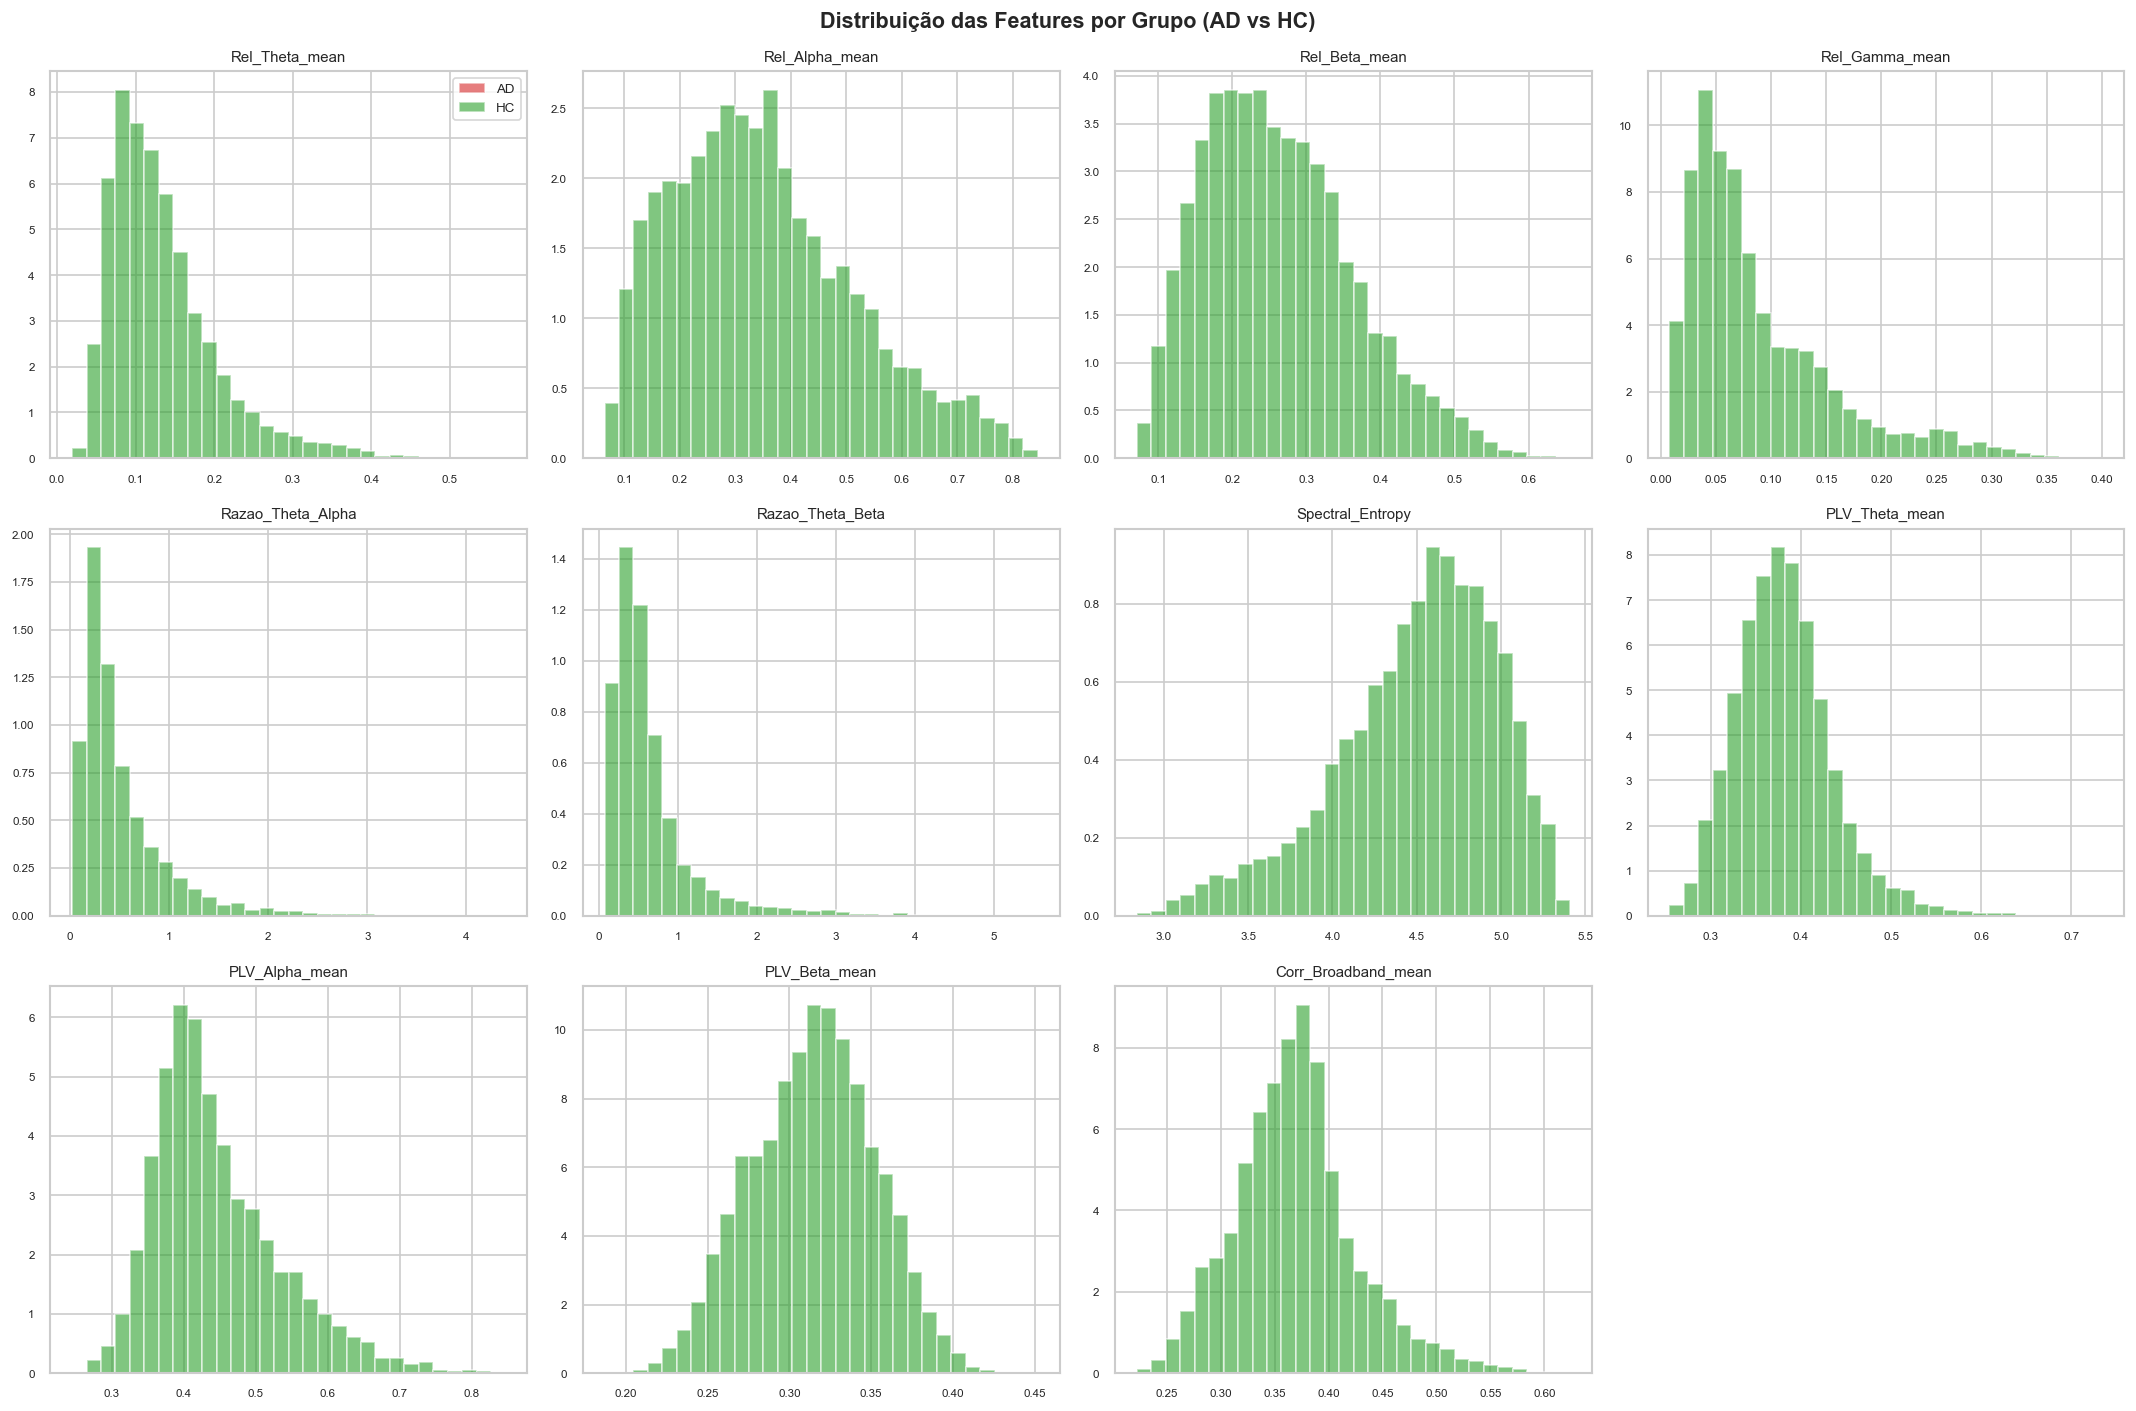

In [33]:
# 1.3 - Resumo Exploratório das Features

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle("Distribuição das Features por Grupo (AD vs HC)", fontsize=13, fontweight="bold")
for i, feat in enumerate(FEATURE_COLS):
    ax = axes[i // 4][i % 4]
    for grp_name, grp_val, col in [("AD", 1, "#d62728"), ("HC", 0, "#2ca02c")]:
        vals = df_clean.loc[df_clean["y"] == grp_val, feat].dropna()
        ax.hist(vals, bins=30, alpha=0.6, color=col, label=grp_name, density=True)
    ax.set_title(feat, fontsize=9)
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=8)
for j in range(len(FEATURE_COLS), 12):
    axes[j // 4][j % 4].set_visible(False)
plt.tight_layout()
plt.show()


---
### Fase 2 — Validação LOSO (Leave-One-Subject-Out)

Em cada fold, **um sujeito completo** é deixado como conjunto de teste; o modelo é treinado em todos os demais sujeitos.

- **Nº de folds** = número de sujeitos únicos.
- **Agregação por sujeito:** a predição final por sujeito é a **média das probabilidades** de todas as suas épocas (decision by voting/averaging).
- Isso reduz o ruído por época e alinha a métrica clínica: diagnóstico por paciente, não por segmento.


In [40]:
# 2.1 -- Definição dos Classificadores

def build_classifiers():
    """Retorna um dicionário de pipelines (Scaler + Classificador)."""
    return {
        "Dummy (Baseline)": Pipeline([
            ("scaler", StandardScaler()),
            ("clf",    DummyClassifier(strategy="stratified", random_state=SEED)),
        ]),
        "SVM (RBF)": Pipeline([
            ("scaler", StandardScaler()),
            ("clf",    CalibratedClassifierCV(
                SVC(kernel="rbf", C=1.0, gamma="scale", random_state=SEED),
                cv=3, method="sigmoid"
            )),
        ]),
        "Random Forest": Pipeline([
            ("scaler", StandardScaler()),
            ("clf",    RandomForestClassifier(
                n_estimators=300, max_depth=None,
                class_weight="balanced", random_state=SEED, n_jobs=-1
            )),
        ]),
        "XGBoost": Pipeline([
            ("scaler", StandardScaler()),
            ("clf",    XGBClassifier(
                n_estimators=300, learning_rate=0.05,
                max_depth=5, subsample=0.8, colsample_bytree=0.8,
                eval_metric="logloss", use_label_encoder=False,
                scale_pos_weight=(y==0).sum() / (y==1).sum(),
                random_state=SEED, verbosity=0
            )),
        ]),
    }

CLASSIFIERS = build_classifiers()
print(f"Classificadores definidos: {list(CLASSIFIERS.keys())}")


Classificadores definidos: ['Dummy (Baseline)', 'SVM (RBF)', 'Random Forest', 'XGBoost']


In [42]:
# 2.2 -- Função de Avaliação: métricas no nível de sujeito, após agregação global
def evaluate_fold(y_true_subj, y_prob_subj, threshold=0.5):
    """
    Computa métricas a partir de predições no nível de sujeito.

    Parâmetros
    ----------
    y_true_subj : array-like, shape (n_sujeitos,)
        Rótulos verdadeiros por sujeito (HC=0, AD=1).
    y_prob_subj : array-like, shape (n_sujeitos,)
        Probabilidade estimada de AD por sujeito.
    threshold : float, default=0.5
        Limiar para converter probabilidade em classe predita.

    Retorna
    -------
    dict
        AUC, Sensitivity, Specificity, F1 e Balanced_Acc.
    """
    y_true_subj = np.asarray(y_true_subj).astype(int)
    y_prob_subj = np.asarray(y_prob_subj, dtype=float)
    y_pred_subj = (y_prob_subj >= threshold).astype(int)

    metrics = {}

    # AUC só existe se houver as duas classes presentes
    if len(np.unique(y_true_subj)) == 2:
        metrics["AUC"] = roc_auc_score(y_true_subj, y_prob_subj)
    else:
        metrics["AUC"] = np.nan

    # Matriz de confusão com labels fixos
    cm = confusion_matrix(y_true_subj, y_pred_subj, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    metrics["Sensitivity"] = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    metrics["Specificity"] = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    metrics["F1"] = f1_score(y_true_subj, y_pred_subj, zero_division=0)

    if len(np.unique(y_true_subj)) == 2:
        metrics["Balanced_Acc"] = balanced_accuracy_score(y_true_subj, y_pred_subj)
    else:
        metrics["Balanced_Acc"] = np.nan

    return metrics


In [67]:
from sklearn.metrics import roc_auc_score

if roc_auc_score(y_true_all, y_prob_all) < 0.5:
    print("[INFO] Invertendo scores (AUC < 0.5)")
    y_prob_all = 1 - y_prob_all

In [70]:
# 2.3 -- Loop LOSO 

from sklearn.base import clone
from sklearn.model_selection import LeaveOneGroupOut
import numpy as np
import pandas as pd
import warnings

loso = LeaveOneGroupOut()
results_loso = {}

unique_subjects = np.unique(groups)
n_folds_loso = len(unique_subjects)
print(f"LOSO: {n_folds_loso} folds (1 sujeito de teste por fold)\n")


def _positive_class_score(pipe, X_test, positive_class=1):
    """
    Retorna um score para a classe positiva (1) de forma robusta.
    - Usa a coluna correta de predict_proba via pipe.classes_
    - Se o modelo foi treinado com apenas 1 classe, devolve score constante
    - Se só houver decision_function, converte para escala [0, 1] via sigmoide
    """
    if hasattr(pipe, "predict_proba"):
        proba = pipe.predict_proba(X_test)
        classes = np.asarray(getattr(pipe, "classes_", []))

        # Caso binário normal: pega a coluna da classe positiva pelo rótulo real
        if positive_class in classes and proba.ndim == 2 and proba.shape[1] >= 1:
            pos_idx = int(np.where(classes == positive_class)[0][0])
            return proba[:, pos_idx]

        # Caso degenerado: o modelo viu só uma classe no treino
        if len(classes) == 1:
            only_class = classes[0]
            return np.ones(len(X_test), dtype=float) if only_class == positive_class else np.zeros(len(X_test), dtype=float)

        # Fallback seguro
        return np.asarray(proba).ravel()

    if hasattr(pipe, "decision_function"):
        score = pipe.decision_function(X_test)
        score = np.asarray(score).ravel()
        return 1.0 / (1.0 + np.exp(-score))  # sigmoide para faixa [0, 1]

    # Último fallback
    return np.asarray(pipe.predict(X_test)).astype(float)


for clf_name, pipeline in CLASSIFIERS.items():
    print(f"  Treinando [{clf_name}]...", end=" ", flush=True)

    y_true_all = []
    y_prob_all = []

    for train_idx, test_idx in loso.split(X, y, groups):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        grp_test = groups[test_idx]

        train_classes = np.unique(y_train)

        # Se o fold vier com apenas uma classe no treino, o modelo não aprende
        # uma fronteira válida. Em vez de quebrar com erro obscurecido, geramos
        # um aviso explícito e seguimos com score constante.
        if len(train_classes) < 2:
            warnings.warn(
                f"[{clf_name}] Fold degenerado: treino com apenas uma classe ({train_classes[0]}). "
                f"Usando score constante no conjunto de teste."
            )
            y_score = np.full(len(X_test), float(train_classes[0]), dtype=float)
        else:
            pipe = clone(pipeline)
            pipe.fit(X_train, y_train)
            y_score = _positive_class_score(pipe, X_test, positive_class=1)

        # Agregação por sujeito: média dos scores das épocas do sujeito
        for s in np.unique(grp_test):
            mask = (grp_test == s)
            y_true_subj = int(y_test[mask][0])
            y_prob_subj = float(np.mean(y_score[mask]))

            y_true_all.append(y_true_subj)
            y_prob_all.append(y_prob_subj)

    y_true_all = np.asarray(y_true_all, dtype=int)
    y_prob_all = np.asarray(y_prob_all, dtype=float)

    # Avaliação final no nível de sujeito
    metrics = evaluate_fold(y_true_all, y_prob_all, threshold=0.5)

    results_loso[clf_name] = {
        "y_true": y_true_all,
        "y_prob": y_prob_all,
        "metrics": metrics
    }

    print(
        f"AUC={metrics['AUC']:.3f}  |  "
        f"Sens={metrics['Sensitivity']:.3f}  "
        f"Spec={metrics['Specificity']:.3f}  "
        f"F1={metrics['F1']:.3f}"
    )

print("\nLOSO concluído.")


LOSO: 67 folds (1 sujeito de teste por fold)

  Treinando [Dummy (Baseline)]... AUC=0.000  |  Sens=0.029  Spec=0.000  F1=0.029
  Treinando [SVM (RBF)]... AUC=0.647  |  Sens=0.714  Spec=0.562  F1=0.676
  Treinando [Random Forest]... AUC=0.715  |  Sens=0.686  Spec=0.656  F1=0.686
  Treinando [XGBoost]... AUC=0.707  |  Sens=0.686  Spec=0.656  F1=0.686

LOSO concluído.


In [74]:
# 2.4 -- Resumo LOSO em Tabela 
import pandas as pd

rows_loso = []
expected_metrics = ["AUC", "Sensitivity", "Specificity", "F1", "Balanced_Acc"]

for clf_name, result_dict in results_loso.items():
    metrics = result_dict["metrics"]  # dicionário com as 5 métricas
    for metric in expected_metrics:
        value = metrics.get(metric, np.nan)
        rows_loso.append({
            "Classifier": clf_name,
            "Metric"    : metric,
            "Value"     : value
        })

df_loso_summary = pd.DataFrame(rows_loso)

# Pivot para formato tabular (classificadores nas linhas, métricas nas colunas)
pivot_loso = df_loso_summary.pivot_table(
    index="Classifier", columns="Metric", values="Value"
).round(4)

print("\n── LOSO: Resultados Globais por Sujeito (Agregado) ──")
display(pivot_loso[expected_metrics])



── LOSO: Resultados Globais por Sujeito (Agregado) ──


Metric,AUC,Sensitivity,Specificity,F1,Balanced_Acc
Classifier,,,,,
Dummy (Baseline),0.0000,0.0286,0.0000,0.0294,0.0143
Random Forest,0.7152,0.6857,0.6562,0.6857,0.6710
SVM (RBF),0.6473,0.7143,0.5625,0.6757,0.6384
XGBoost,0.7071,0.6857,0.6562,0.6857,0.6710


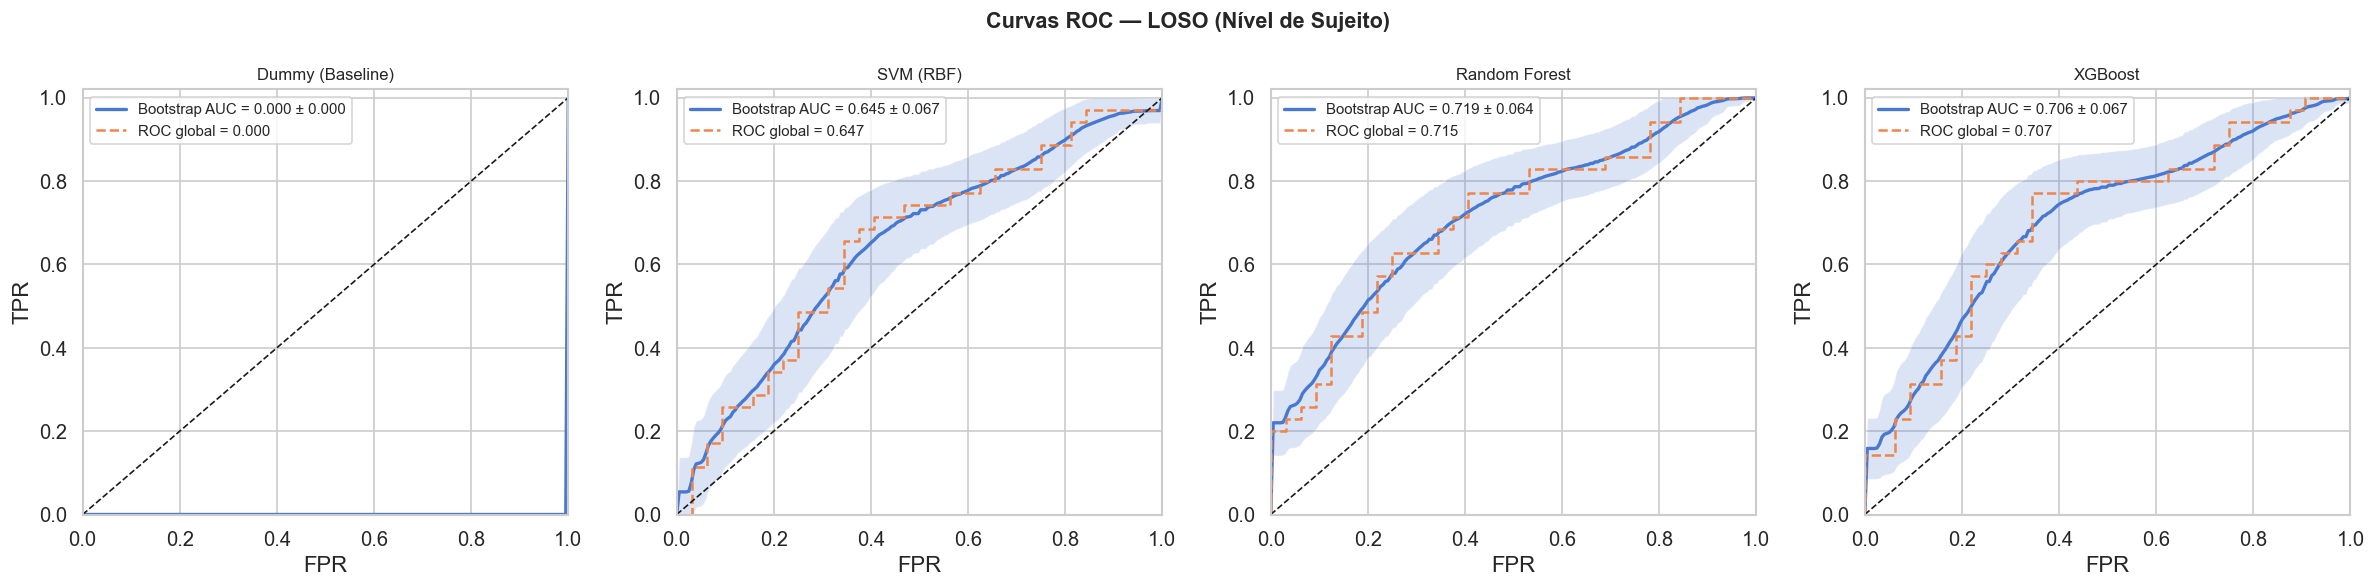

In [76]:
# 2.5 -- Curvas ROC lOSO
#
# Nesta versão:
# - usa as predições agregadas por sujeito já salvas em results_loso
# - calcula a ROC global por classificador
# - estima uma curva média via bootstrap no nível de sujeito

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

loso_roc_data = {}

classifier_names = list(results_loso.keys())
fig, axes = plt.subplots(1, len(classifier_names), figsize=(5 * len(classifier_names), 5))
axes = np.atleast_1d(axes)

fig.suptitle("Curvas ROC — LOSO (Nível de Sujeito)", fontsize=13, fontweight="bold")

mean_fpr = np.linspace(0, 1, 200)
rng = np.random.default_rng(42)
n_boot = 1000

for ax, clf_name in zip(axes, classifier_names):
    y_true = np.asarray(results_loso[clf_name]["y_true"], dtype=int)
    y_prob = np.asarray(results_loso[clf_name]["y_prob"], dtype=float)

    if len(np.unique(y_true)) < 2:
        ax.text(
            0.5, 0.5,
            "Apenas uma classe\n(não é possível calcular ROC)",
            ha="center", va="center", transform=ax.transAxes
        )
        ax.plot([0, 1], [0, 1], "k--", lw=1)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.02)
        ax.set_xlabel("FPR")
        ax.set_ylabel("TPR")
        ax.set_title(clf_name, fontsize=10)
        continue

    # ROC global usando todos os sujeitos
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    # Bootstrap para curva média + variabilidade
    tpr_boot = []
    auc_boot = []

    n_samples = len(y_true)
    for _ in range(n_boot):
        idx = rng.integers(0, n_samples, n_samples)
        yt = y_true[idx]
        yp = y_prob[idx]

        if len(np.unique(yt)) < 2:
            continue

        fpr_b, tpr_b, _ = roc_curve(yt, yp)
        tpr_i = np.interp(mean_fpr, fpr_b, tpr_b)
        tpr_i[0] = 0.0

        tpr_boot.append(tpr_i)
        auc_boot.append(auc(fpr_b, tpr_b))

    tpr_boot = np.asarray(tpr_boot)
    auc_boot = np.asarray(auc_boot)

    loso_roc_data[clf_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc_auc,
        "mean_fpr": mean_fpr,
        "boot_tpr": tpr_boot,
        "boot_auc": auc_boot,
    }

    if len(tpr_boot) > 0:
        mean_tpr = tpr_boot.mean(axis=0)
        std_tpr = tpr_boot.std(axis=0)
        mean_auc = auc_boot.mean()
        std_auc = auc_boot.std()

        ax.plot(mean_fpr, mean_tpr, lw=2, label=f"Bootstrap AUC = {mean_auc:.3f} ± {std_auc:.3f}")
        ax.fill_between(
            mean_fpr,
            np.clip(mean_tpr - std_tpr, 0, 1),
            np.clip(mean_tpr + std_tpr, 0, 1),
            alpha=0.2
        )

    ax.plot(fpr, tpr, lw=1.5, linestyle="--", label=f"ROC global = {roc_auc:.3f}")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.set_title(clf_name, fontsize=10)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


---
### Fase 3 — Validação GroupKFold (K=10)

Divide os sujeitos em **K grupos** de forma que cada sujeito apareça em **exatamente um fold de teste**.
Isso garante a mesma propriedade anti-leakage do LOSO, mas com:
- Menor variância nas estimativas (folds maiores).
- Menor custo computacional (K folds vs N_sujeitos folds).

A agregação por sujeito dentro de cada fold segue o mesmo protocolo do LOSO.


In [77]:
# 3.1 -- Loop GroupKFold

gkf = GroupKFold(n_splits=N_SPLITS_KF)
results_gkf = {clf_name: [] for clf_name in CLASSIFIERS}

print(f"GroupKFold: {N_SPLITS_KF} folds\n")

for clf_name, pipeline in CLASSIFIERS.items():
    print(f"  Treinando [{clf_name}]...", end=" ", flush=True)
    fold_metrics = []

    for train_idx, test_idx in gkf.split(X, y, groups):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        grp_test        = groups[test_idx]

        pipe = clone(pipeline)
        pipe.fit(X_train, y_train)
        y_prob = pipe.predict_proba(X_test)[:, 1]

        subj_ids_test  = np.unique(grp_test)
        y_prob_subj    = np.array([y_prob[grp_test == s].mean()  for s in subj_ids_test])
        y_true_subj    = np.array([y_test[grp_test == s][0]      for s in subj_ids_test])

        fold_metrics.append(evaluate_fold(y_true_subj, y_prob_subj))

    results_gkf[clf_name] = fold_metrics
    df_m = pd.DataFrame(fold_metrics)
    print(f"AUC={df_m['AUC'].mean():.3f} ± {df_m['AUC'].std():.3f}  |  "
          f"Sens={df_m['Sensitivity'].mean():.3f}  "
          f"Spec={df_m['Specificity'].mean():.3f}  "
          f"F1={df_m['F1'].mean():.3f}")

print("\nGroupKFold concluído.")


GroupKFold: 10 folds

  Treinando [Dummy (Baseline)]... AUC=0.627 ± 0.228  |  Sens=0.575  Spec=0.613  F1=0.502
  Treinando [SVM (RBF)]... AUC=0.719 ± 0.195  |  Sens=0.715  Spec=0.575  F1=0.635
  Treinando [Random Forest]... AUC=0.757 ± 0.170  |  Sens=0.715  Spec=0.615  F1=0.662
  Treinando [XGBoost]... AUC=0.716 ± 0.234  |  Sens=0.728  Spec=0.635  F1=0.706

GroupKFold concluído.


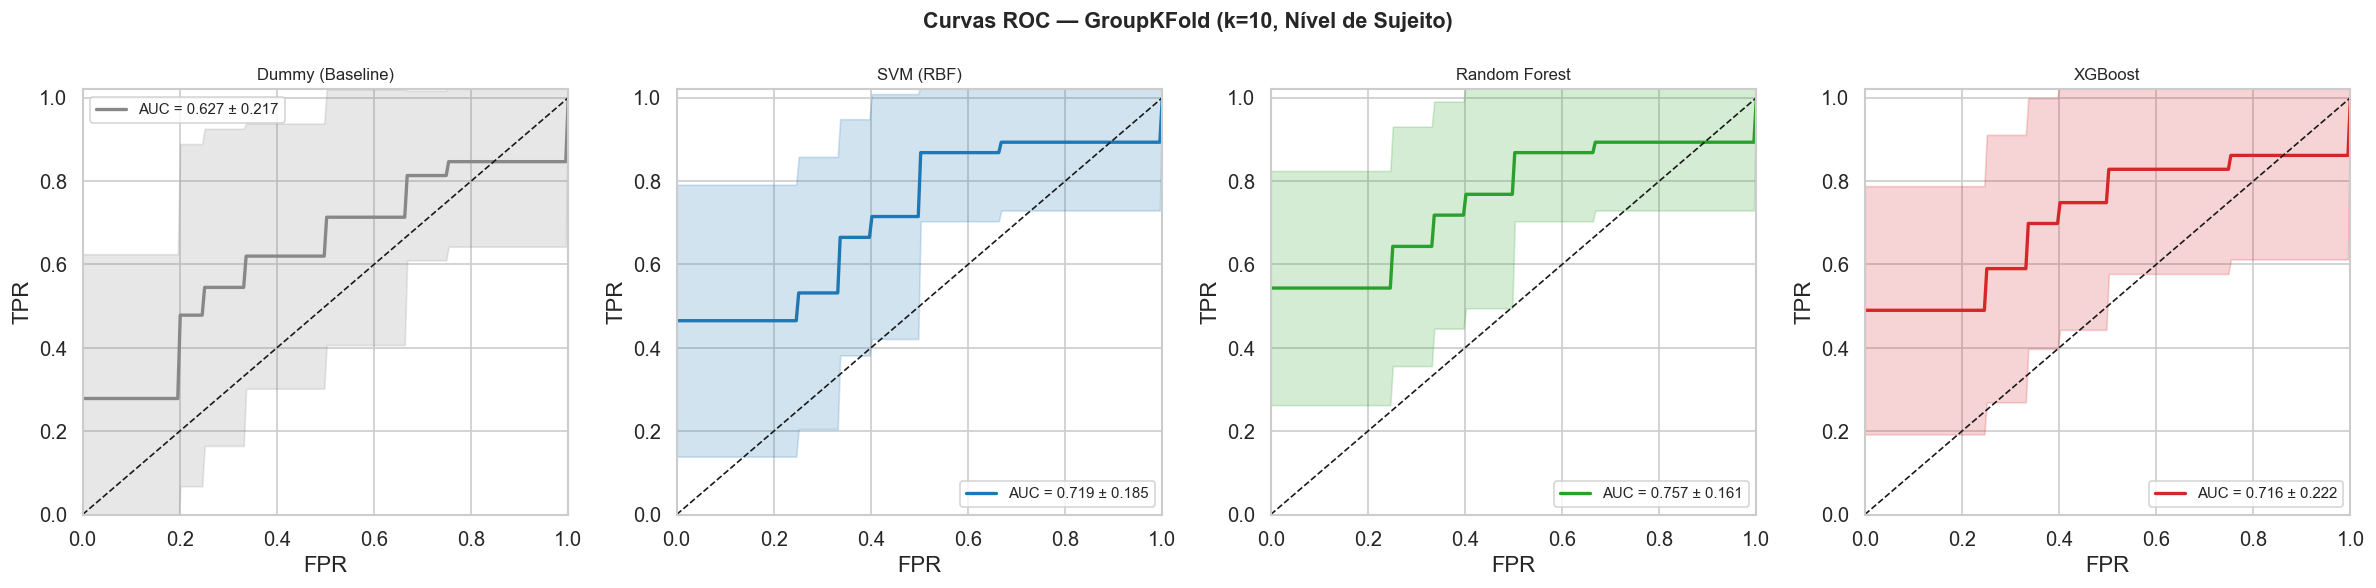

In [79]:
# 3.3 -- Curvas ROC Médias (GroupKFold)

gkf_roc_data = {}

fig, axes = plt.subplots(1, len(CLASSIFIERS), figsize=(5 * len(CLASSIFIERS), 5))
fig.suptitle(f"Curvas ROC — GroupKFold (k={N_SPLITS_KF}, Nível de Sujeito)",
             fontsize=13, fontweight="bold")

for ax, (clf_name, _), color in zip(axes, results_gkf.items(), palette):
    gkf_cv   = GroupKFold(n_splits=N_SPLITS_KF)
    mean_fpr = np.linspace(0, 1, 200)
    tpr_interp, auc_vals = [], []

    for train_idx, test_idx in gkf_cv.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        grp_te     = groups[test_idx]

        p = clone(CLASSIFIERS[clf_name])
        p.fit(X_tr, y_tr)
        y_pr = p.predict_proba(X_te)[:, 1]

        subj_ids = np.unique(grp_te)
        y_pr_s   = np.array([y_pr[grp_te == s].mean() for s in subj_ids])
        y_true_s = np.array([y_te[grp_te == s][0]     for s in subj_ids])

        if len(np.unique(y_true_s)) < 2:
            continue
        fpr, tpr, _ = roc_curve(y_true_s, y_pr_s)
        tpr_interp.append(np.interp(mean_fpr, fpr, tpr))
        auc_vals.append(auc(fpr, tpr))

    gkf_roc_data[clf_name] = (mean_fpr, np.array(tpr_interp), auc_vals)

    if tpr_interp:
        mean_tpr = np.mean(tpr_interp, axis=0)
        std_tpr  = np.std(tpr_interp, axis=0)
        mean_auc = np.mean(auc_vals)
        std_auc  = np.std(auc_vals)
        ax.plot(mean_fpr, mean_tpr, color=color, lw=2,
                label=f"AUC = {mean_auc:.3f} ± {std_auc:.3f}")
        ax.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,
                        alpha=0.2, color=color)
    ax.plot([0,1],[0,1], "k--", lw=1)
    ax.set_xlim(0,1); ax.set_ylim(0,1.02)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title(clf_name, fontsize=10)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


---
### Fase 4 — Comparação LOSO vs GroupKFold

Métricas comparadas:
- **AUC médio** ± desvio padrão
- **Sensibilidade, Especificidade, F1** médios
- Teste estatístico de Wilcoxon (pareado por fold em AUC) para os dados disponíveis do GroupKFold


In [81]:
# 4.1 -- Tabela Comparativa 

rows_compare = []
for clf_name in CLASSIFIERS:
    for scheme_name, results in [("LOSO", results_loso), ("GroupKFold", results_gkf)]:
        data = results[clf_name]
        
        # Converte a estrutura para um DataFrame com colunas de métricas
        if isinstance(data, dict) and "metrics" in data:
            # Caso LOSO: métricas globais em um dicionário único
            metrics_dict = data["metrics"]
            # Cria um DataFrame de uma linha (um único "fold")
            df_m = pd.DataFrame([metrics_dict])
        elif isinstance(data, list):
            # Caso GroupKFold: lista de dicionários por fold
            df_m = pd.DataFrame(data)
        else:
            print(f"Estrutura inesperada para {clf_name} ({scheme_name}): {type(data)}")
            continue
        
        # Verifica se as colunas esperadas existem
        expected_cols = ["AUC", "Sensitivity", "Specificity", "F1", "Balanced_Acc"]
        if not all(col in df_m.columns for col in expected_cols):
            print(f"Aviso: faltam colunas em {clf_name} ({scheme_name}). Colunas presentes: {df_m.columns.tolist()}")
            continue
        
        rows_compare.append({
            "Classifier": clf_name,
            "Scheme": scheme_name,
            "AUC_mean": df_m["AUC"].mean(),
            "AUC_std": df_m["AUC"].std(),
            "Sens_mean": df_m["Sensitivity"].mean(),
            "Spec_mean": df_m["Specificity"].mean(),
            "F1_mean": df_m["F1"].mean(),
            "BAcc_mean": df_m["Balanced_Acc"].mean(),
            "N_folds": len(df_m),
        })

df_compare = pd.DataFrame(rows_compare)

# Formatação da coluna AUC para exibição
df_compare["AUC_fmt"] = df_compare.apply(
    lambda r: f"{r.AUC_mean:.3f} ± {r.AUC_std:.3f}" if pd.notna(r.AUC_std) else f"{r.AUC_mean:.3f}",
    axis=1
)

# Tabela pivotada para comparar esquemas lado a lado
pivot_compare = df_compare.pivot_table(
    index="Classifier", columns="Scheme",
    values=["AUC_mean", "Sens_mean", "Spec_mean", "F1_mean", "BAcc_mean"]
).round(4)

print("── Comparação LOSO vs GroupKFold ──")
display(pivot_compare)


── Comparação LOSO vs GroupKFold ──


AUC_mean          BAcc_mean            F1_mean          \
Scheme           GroupKFold    LOSO GroupKFold    LOSO GroupKFold    LOSO   
Classifier                                                                  
Dummy (Baseline)     0.6267  0.0000     0.5942  0.0143     0.5019  0.0294   
Random Forest        0.7567  0.7152     0.6650  0.6710     0.6617  0.6857   
SVM (RBF)            0.7189  0.6473     0.6450  0.6384     0.6350  0.6757   
XGBoost              0.7156  0.7071     0.6817  0.6710     0.7061  0.6857   

                  Sens_mean          Spec_mean          
Scheme           GroupKFold    LOSO GroupKFold    LOSO  
Classifier                                              
Dummy (Baseline)     0.5750  0.0286     0.6133  0.0000  
Random Forest        0.7150  0.6857     0.6150  0.6562  
SVM (RBF)            0.7150  0.7143     0.5750  0.5625  
XGBoost              0.7283  0.6857     0.6350  0.6562

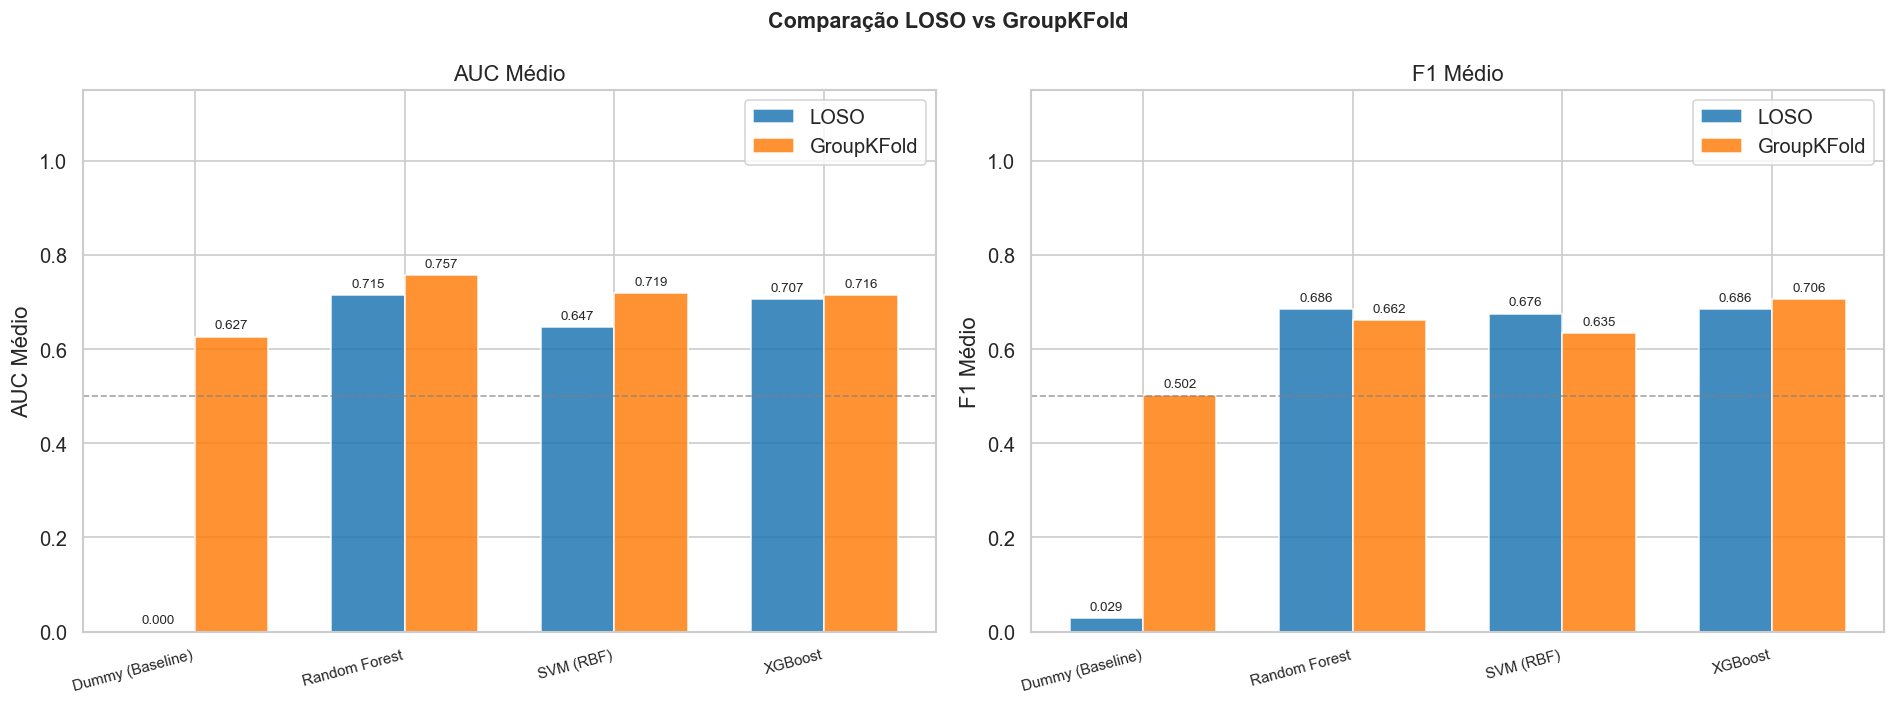

In [82]:
# 4.2 -- Barplot: AUC LOSO vs GroupKFold por Classificador

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Comparação LOSO vs GroupKFold", fontsize=13, fontweight="bold")

metrics_to_plot = ["AUC_mean", "F1_mean"]
metric_labels   = ["AUC Médio", "F1 Médio"]

for ax, metric, label in zip(axes, metrics_to_plot, metric_labels):
    df_plot = df_compare.pivot(index="Classifier", columns="Scheme", values=metric)
    x       = np.arange(len(df_plot))
    w       = 0.35
    clrs    = {"LOSO": "#1f77b4", "GroupKFold": "#ff7f0e"}
    for i, scheme in enumerate(["LOSO", "GroupKFold"]):
        if scheme not in df_plot.columns:
            continue
        bars = ax.bar(x + (i - 0.5) * w, df_plot[scheme].values,
                      width=w, color=clrs[scheme], alpha=0.85, label=scheme)
        ax.bar_label(bars, fmt="%.3f", fontsize=8, padding=3)
    ax.set_xticks(x)
    ax.set_xticklabels(df_plot.index, rotation=15, ha="right", fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.legend()
    ax.axhline(0.5, color="gray", lw=1, ls="--", alpha=0.7)

plt.tight_layout()
plt.show()


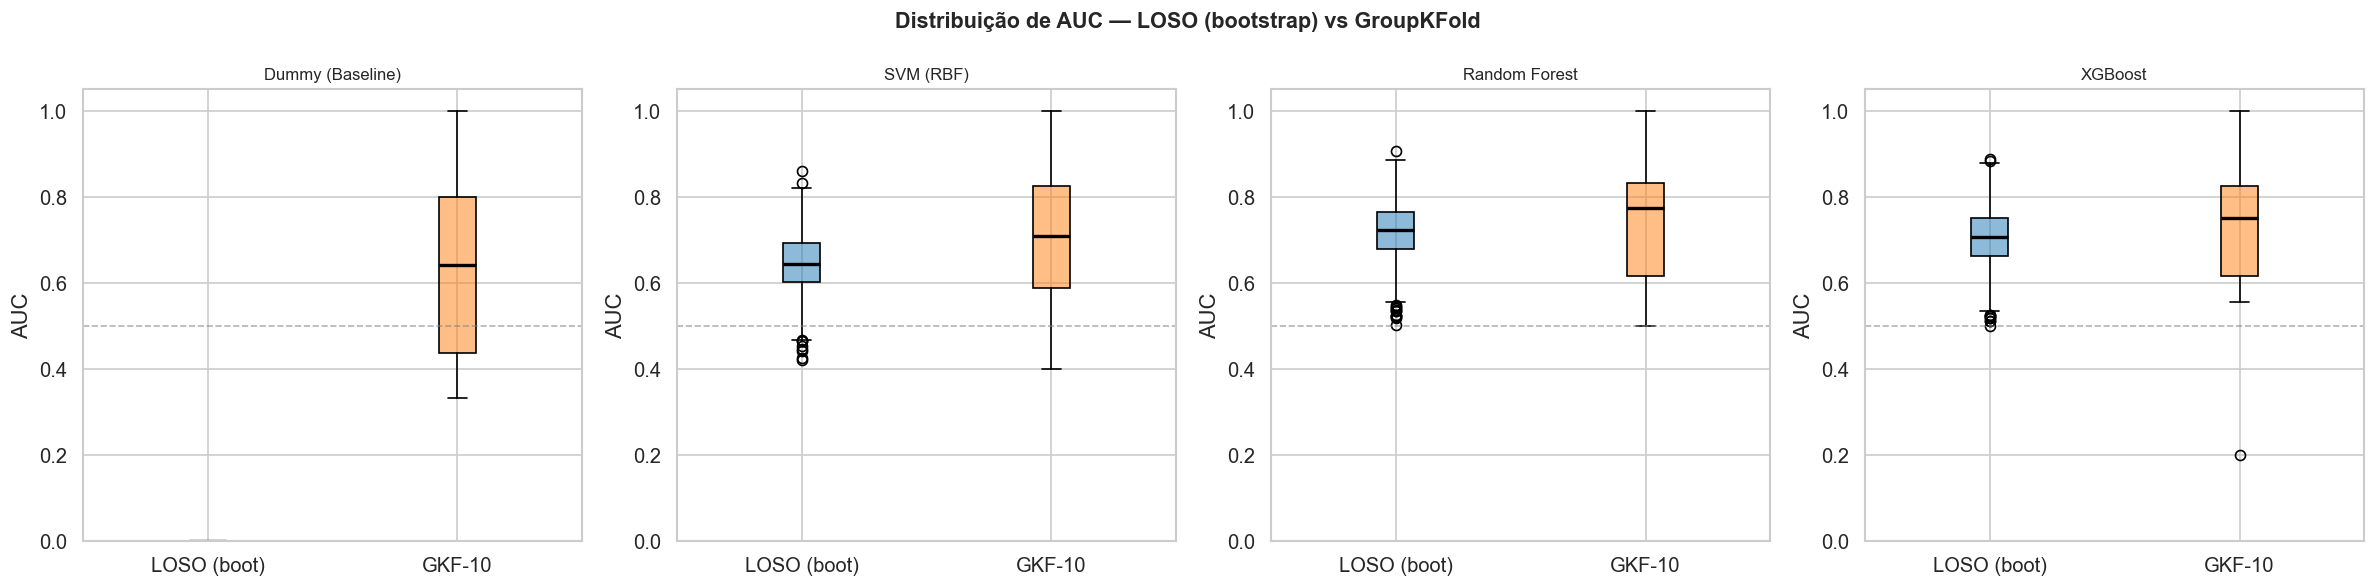

In [85]:
# 4.3 -- Boxplot: Distribuição de AUC por Fold

fig, axes = plt.subplots(1, len(CLASSIFIERS), figsize=(5 * len(CLASSIFIERS), 5))
fig.suptitle("Distribuição de AUC — LOSO (bootstrap) vs GroupKFold",
             fontsize=13, fontweight="bold")

for ax, clf_name in zip(axes, CLASSIFIERS):
    
    auc_loso = loso_roc_data[clf_name]["boot_auc"]   # ← bootstrap
    auc_gkf  = [m["AUC"] for m in results_gkf[clf_name]]

    bp = ax.boxplot(
        [auc_loso, auc_gkf],
        labels=["LOSO (boot)", f"GKF-{N_SPLITS_KF}"],
        patch_artist=True,
        medianprops={"color": "black", "lw": 2},
    )

    bp["boxes"][0].set_facecolor("#1f77b480")
    bp["boxes"][1].set_facecolor("#ff7f0e80")

    ax.set_title(clf_name, fontsize=10)
    ax.set_ylabel("AUC")
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color="gray", lw=1, ls="--", alpha=0.6)

plt.tight_layout()
plt.show()


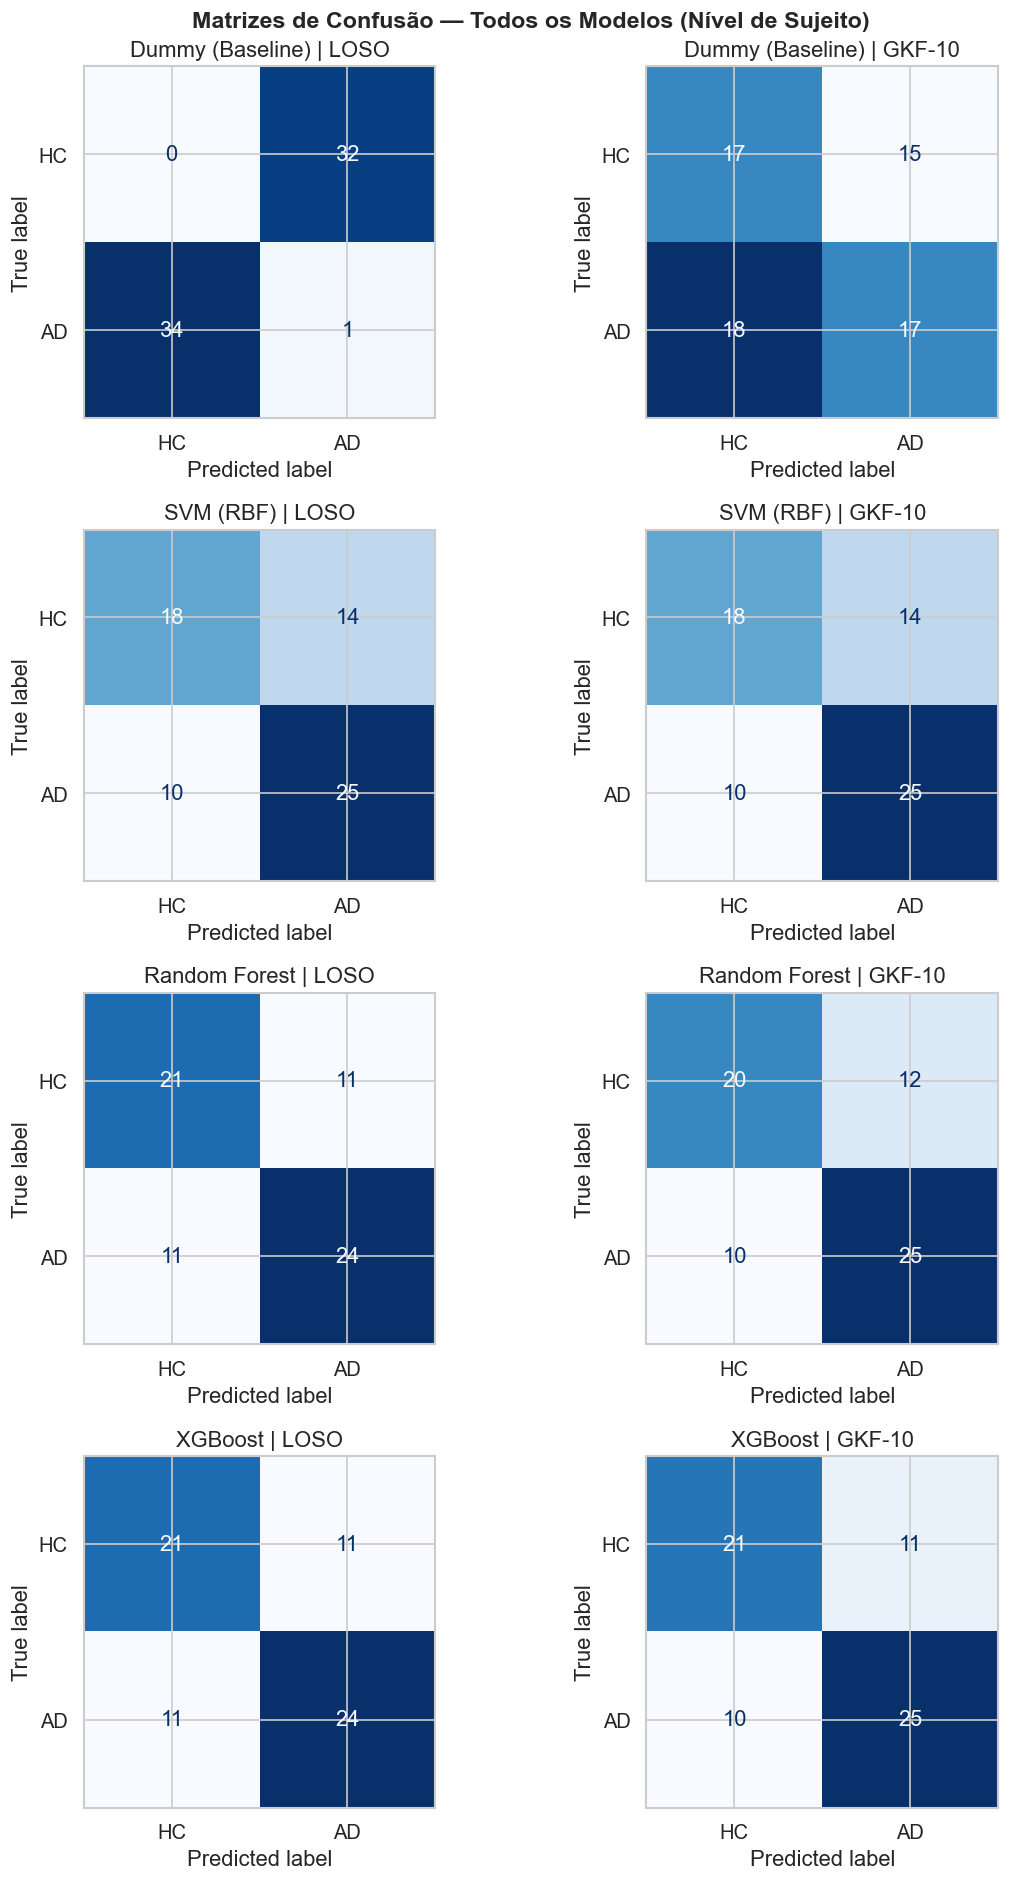

In [88]:
# 4.4 -- Matrizes de Confusão 

import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.base import clone
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold


# =========================================================
# Função robusta para obter score da classe positiva
# =========================================================
def get_score(pipe, X):
    if hasattr(pipe, "predict_proba"):
        proba = pipe.predict_proba(X)
        classes = pipe.classes_

        if 1 in classes:
            idx = np.where(classes == 1)[0][0]
            return proba[:, idx]

        # caso degenerado
        return np.zeros(len(X))

    elif hasattr(pipe, "decision_function"):
        score = pipe.decision_function(X)
        return 1 / (1 + np.exp(-score))  # sigmoid

    else:
        return pipe.predict(X)


# =========================================================
# Agregação por sujeito
# =========================================================
def aggregate_confusion(scheme_cv, X, y, groups, pipeline, threshold=0.5):
    all_true, all_pred = [], []

    for train_idx, test_idx in scheme_cv.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        grp_te     = groups[test_idx]

        # fold degenerado
        if len(np.unique(y_tr)) < 2:
            warnings.warn("Fold com uma única classe no treino.")
            y_score = np.full(len(X_te), y_tr[0])
        else:
            pipe = clone(pipeline)
            pipe.fit(X_tr, y_tr)
            y_score = get_score(pipe, X_te)

        # agregação por sujeito
        for s in np.unique(grp_te):
            mask = grp_te == s

            y_true_subj = y_te[mask][0]
            y_score_subj = np.mean(y_score[mask])
            y_pred_subj = int(y_score_subj >= threshold)

            all_true.append(y_true_subj)
            all_pred.append(y_pred_subj)

    return np.array(all_true), np.array(all_pred)


# =========================================================
# Plot para TODOS os modelos
# =========================================================

schemes = [
    ("LOSO", LeaveOneGroupOut()),
    (f"GKF-{N_SPLITS_KF}", GroupKFold(n_splits=N_SPLITS_KF))
]

n_models = len(CLASSIFIERS)
fig, axes = plt.subplots(n_models, 2, figsize=(10, 4 * n_models))

if n_models == 1:
    axes = np.expand_dims(axes, axis=0)

fig.suptitle("Matrizes de Confusão — Todos os Modelos (Nível de Sujeito)",
             fontsize=14, fontweight="bold")

for i, (clf_name, pipeline) in enumerate(CLASSIFIERS.items()):
    for j, (scheme_name, scheme_cv) in enumerate(schemes):

        ax = axes[i, j]

        y_true_agg, y_pred_agg = aggregate_confusion(
            scheme_cv, X, y, groups, pipeline
        )

        cm = confusion_matrix(y_true_agg, y_pred_agg, labels=[0, 1])

        disp = ConfusionMatrixDisplay(cm, display_labels=["HC", "AD"])
        disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format="d")

        ax.set_title(f"{clf_name} | {scheme_name}")

plt.tight_layout()
plt.show()


---
### Fase 5 — Importância de Features

Duas perspectivas:
1. **Importância nativa do Random Forest** (média de impureza de Gini, rápida).
2. **SHAP values** para o XGBoost treinado em todos os dados (se SHAP instalado).


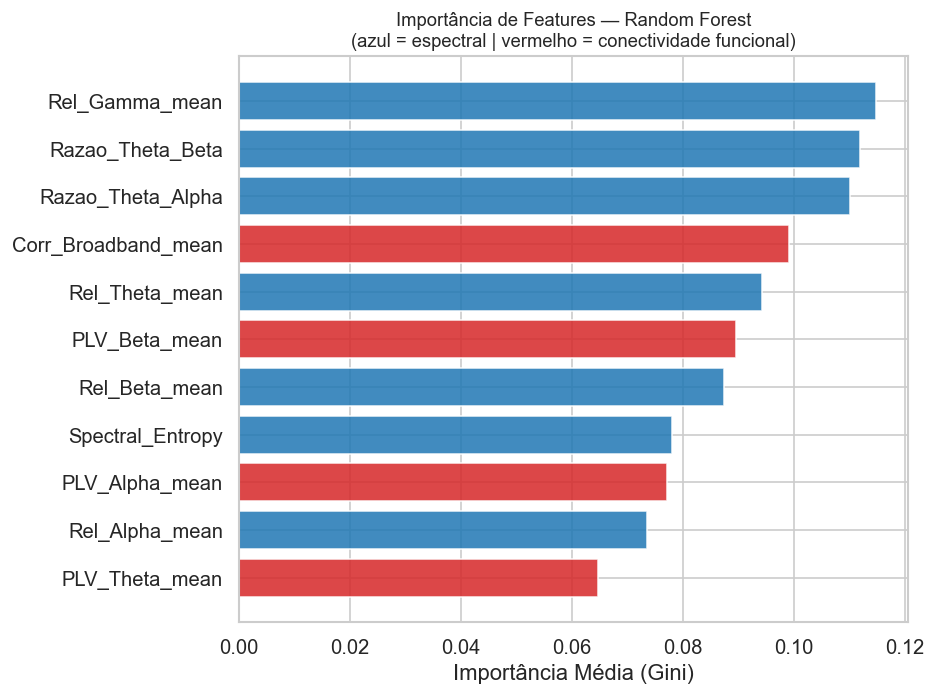


Top 5 features:


,Feature,Importance
3,Rel_Gamma_mean,0.114794
5,Razao_Theta_Beta,0.111804
4,Razao_Theta_Alpha,0.109981
10,Corr_Broadband_mean,0.099007
0,Rel_Theta_mean,0.094150


In [90]:
# 5.1 -- Importância de Features: Random Forest (nativa)

rf_pipe = clone(CLASSIFIERS["Random Forest"])
rf_pipe.fit(X, y)
importances = rf_pipe.named_steps["clf"].feature_importances_
feat_imp_df = pd.DataFrame({
    "Feature"   : FEATURE_COLS,
    "Importance": importances,
}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#d62728" if "PLV" in f or "Corr" in f else "#1f77b4"
          for f in feat_imp_df["Feature"]]
ax.barh(feat_imp_df["Feature"], feat_imp_df["Importance"], color=colors, alpha=0.85)
ax.set_xlabel("Importância Média (Gini)")
ax.set_title("Importância de Features — Random Forest\n"
             "(azul = espectral | vermelho = conectividade funcional)",
             fontsize=11)
plt.tight_layout()
plt.show()

print("\nTop 5 features:")
display(feat_imp_df.sort_values("Importance", ascending=False).head(5))


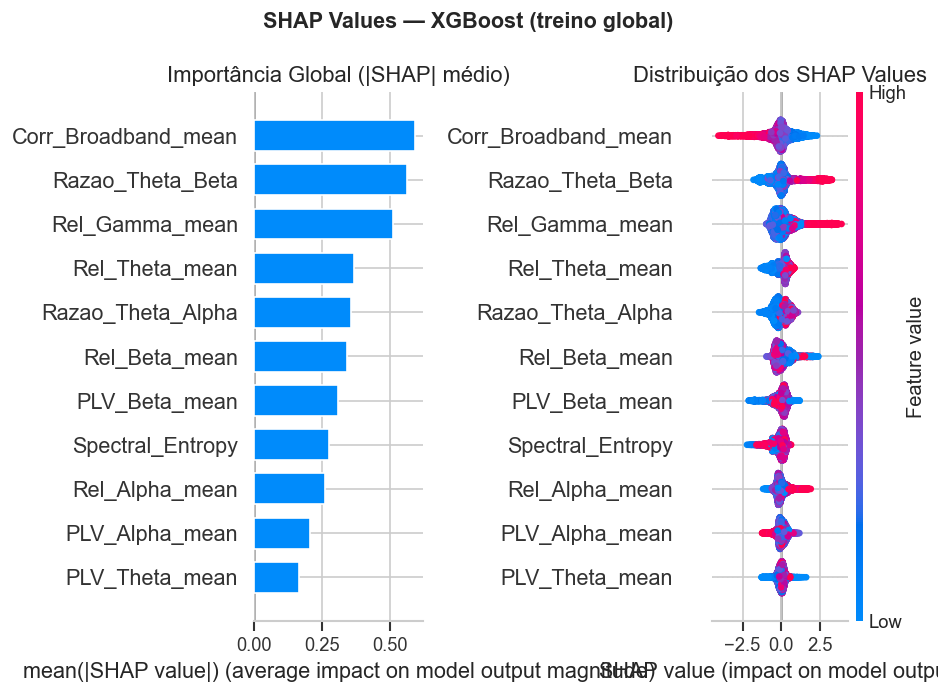

In [91]:
# 5.2 -- SHAP Values (XGBoost, treino global)
#
# SHAP explica a contribuição de cada feature para cada predição individual.
# Aqui treinamos o XGBoost em todos os dados apenas para interpretabilidade.
# Para avaliação de generalização, confiar nos resultados de CV acima.

if SHAP_AVAILABLE:
    xgb_pipe = clone(CLASSIFIERS["XGBoost"])
    xgb_pipe.fit(X, y)

    # SHAP espera entrada já escalada
    X_scaled = xgb_pipe.named_steps["scaler"].transform(X)
    explainer = shap.TreeExplainer(xgb_pipe.named_steps["clf"])
    shap_vals = explainer.shap_values(X_scaled)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("SHAP Values — XGBoost (treino global)",
                 fontsize=13, fontweight="bold")

    plt.sca(axes[0])
    shap.summary_plot(shap_vals, X_scaled, feature_names=FEATURE_COLS,
                      show=False, plot_type="bar")
    axes[0].set_title("Importância Global (|SHAP| médio)")

    plt.sca(axes[1])
    shap.summary_plot(shap_vals, X_scaled, feature_names=FEATURE_COLS, show=False)
    axes[1].set_title("Distribuição dos SHAP Values")

    plt.tight_layout()
    plt.show()
else:
    print("SHAP não disponível. Instale com: pip install shap")
    print("Exibindo importância do XGBoost nativa como alternativa.")

    xgb_pipe = clone(CLASSIFIERS["XGBoost"])
    xgb_pipe.fit(X, y)
    xgb_imp = xgb_pipe.named_steps["clf"].feature_importances_
    xgb_imp_df = pd.DataFrame({
        "Feature": FEATURE_COLS, "Gain": xgb_imp
    }).sort_values("Gain", ascending=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    colors = ["#d62728" if "PLV" in f or "Corr" in f else "#ff7f0e"
              for f in xgb_imp_df["Feature"]]
    ax.barh(xgb_imp_df["Feature"], xgb_imp_df["Gain"], color=colors, alpha=0.85)
    ax.set_xlabel("Gain de Feature (XGBoost)")
    ax.set_title("Importância de Features — XGBoost\n"
                 "(laranja = espectral | vermelho = conectividade)")
    plt.tight_layout()
    plt.show()


In [93]:
# 5.3 -- Resumo Final: Tabela Comparativa Completa (CORRIGIDO)

print("\n" + "="*70)
print("  RESUMO FINAL — COMPARAÇÃO LOSO vs GroupKFold")
print("="*70)

summary_rows = []

for clf_name in CLASSIFIERS:

    # =========================
    #  LOSO (resultado único)
    # =========================
    m = results_loso[clf_name]["metrics"]

    summary_rows.append({
        "Classificador" : clf_name,
        "Esquema"       : "LOSO",
        "AUC"           : f"{m['AUC']:.3f}",
        "Sensibilidade" : f"{m['Sensitivity']:.3f}",
        "Especificidade": f"{m['Specificity']:.3f}",
        "F1"            : f"{m['F1']:.3f}",
        "Bal. Acc."     : f"{m['Balanced_Acc']:.3f}",
        "N Folds"       : len(results_loso[clf_name]["y_true"]),  # nº sujeitos
    })

    # =========================
    #  GroupKFold (vários folds)
    # =========================
    df_m = pd.DataFrame(results_gkf[clf_name])

    summary_rows.append({
        "Classificador" : clf_name,
        "Esquema"       : f"GroupKFold-{N_SPLITS_KF}",
        "AUC"           : f"{df_m['AUC'].mean():.3f} ± {df_m['AUC'].std():.3f}",
        "Sensibilidade" : f"{df_m['Sensitivity'].mean():.3f}",
        "Especificidade": f"{df_m['Specificity'].mean():.3f}",
        "F1"            : f"{df_m['F1'].mean():.3f}",
        "Bal. Acc."     : f"{df_m['Balanced_Acc'].mean():.3f}",
        "N Folds"       : len(df_m),
    })

df_final_summary = pd.DataFrame(summary_rows)
display(df_final_summary)

print("\nNotas de interpretação:")
print(" - LOSO = avaliação mais realista (novo sujeito).")
print(" - GroupKFold = estimativa mais estável, porém otimista.")
print(" - Diferença entre os dois indica capacidade de generalização.")
print(" - AUC ~0.65–0.75 é típico para EEG resting-state em AD.")



  RESUMO FINAL — COMPARAÇÃO LOSO vs GroupKFold


,Classificador,Esquema,AUC,Sensibilidade,Especificidade,F1,Bal. Acc.,N Folds
0,Dummy (Baseline),LOSO,0.000,0.029,0.000,0.029,0.014,67
1,Dummy (Baseline),GroupKFold-10,0.627 ± 0.228,0.575,0.613,0.502,0.594,10
2,SVM (RBF),LOSO,0.647,0.714,0.562,0.676,0.638,67
3,SVM (RBF),GroupKFold-10,0.719 ± 0.195,0.715,0.575,0.635,0.645,10
4,Random Forest,LOSO,0.715,0.686,0.656,0.686,0.671,67
5,Random Forest,GroupKFold-10,0.757 ± 0.170,0.715,0.615,0.662,0.665,10
6,XGBoost,LOSO,0.707,0.686,0.656,0.686,0.671,67
7,XGBoost,GroupKFold-10,0.716 ± 0.234,0.728,0.635,0.706,0.682,10



Notas de interpretação:
 - LOSO = avaliação mais realista (novo sujeito).
 - GroupKFold = estimativa mais estável, porém otimista.
 - Diferença entre os dois indica capacidade de generalização.
 - AUC ~0.65–0.75 é típico para EEG resting-state em AD.
